<a href="https://colab.research.google.com/github/ketanp23/deeplearningclass/blob/main/DL_Lab6_Activations_Init_and_Softmax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DL Lab 6 · Activations, Initialization & the Softmax–Cross-Entropy Pair

> **Deep Learning foundations — Lab 6 (Part II).** A deeper companion to **Lab 1**. Run top to bottom
> (Runtime → Run all), read the plain-English notes, and finish the **Your turn 🧪** cell. Built from scratch with
> NumPy so nothing is hidden.

### In plain English
Lab 1 met the neuron. Here we go deeper into the two things that decide whether a deep stack of neurons actually
*trains*: the **activation functions' gradients**, and how we **initialize the weights**. Get initialization wrong and
the very first forward pass either fades to zero or blows up — before any learning happens. We finish with the
**softmax + cross-entropy** pairing and the beautiful way their gradient simplifies.

In [1]:
import numpy as np, matplotlib.pyplot as plt
VIOLET,CYAN,AMBER,GREEN,ROSE="#6C5CE7","#22D3EE","#F59E0B","#10B981","#FB7185"
np.random.seed(0)

## 1 · The activation zoo and their gradients

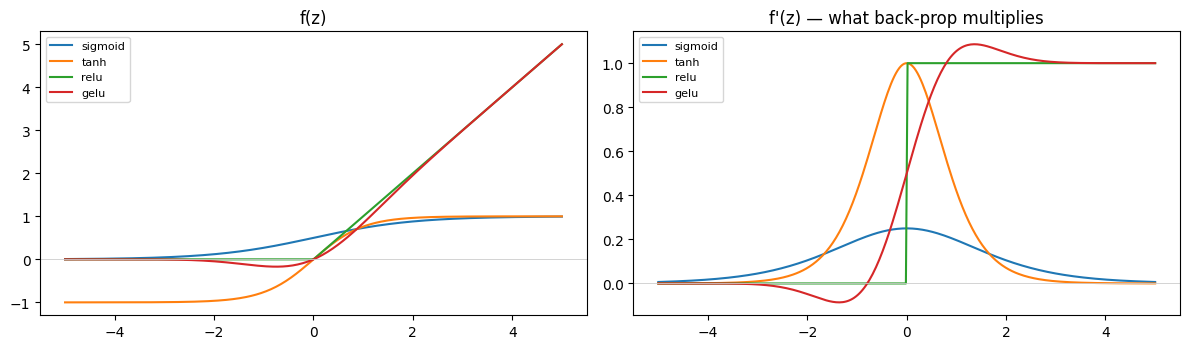

Peak sigmoid gradient: 0.25 (<=0.25 always)


In [2]:
acts = {
 "sigmoid": (lambda z: 1/(1+np.exp(-z)),           lambda z: (s:=1/(1+np.exp(-z)))*(1-s)),
 "tanh":    (lambda z: np.tanh(z),                  lambda z: 1-np.tanh(z)**2),
 "relu":    (lambda z: np.maximum(0,z),             lambda z: (z>0).astype(float)),
 "gelu":    (lambda z: 0.5*z*(1+np.tanh(0.7979*(z+0.044715*z**3))),
            lambda z: 0.5*(1+np.tanh(0.7979*(z+0.044715*z**3)))+0.4*z*(1/np.cosh(0.7979*(z+0.044715*z**3)))**2),
}
z=np.linspace(-5,5,300)
fig,ax=plt.subplots(1,2,figsize=(12,3.6))
for name,(f,df) in acts.items():
    ax[0].plot(z,f(z),label=name); ax[1].plot(z,df(z),label=name)
ax[0].set_title("f(z)"); ax[1].set_title("f'(z) — what back-prop multiplies")
for a in ax: a.axhline(0,color="#ccc",lw=.6); a.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Peak sigmoid gradient:", round(float(acts['sigmoid'][1](np.array([0.0]))[0]),3), "(<=0.25 always)")

## 2 · Why initialization decides everything
Send a random signal through many layers. If each layer's weights are too small the activations shrink to 0; too big
and they explode. We want the **variance to stay roughly constant** across depth. Watch three schemes.

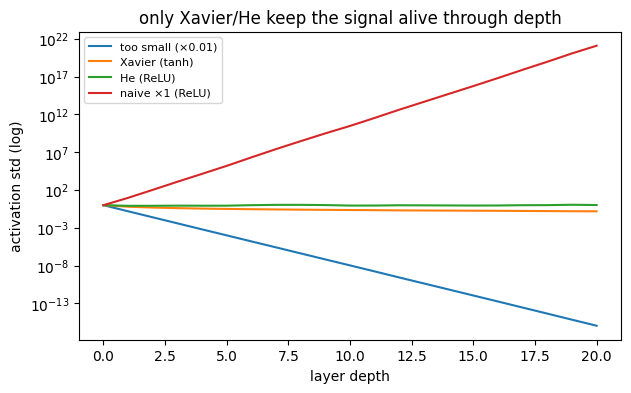

In [3]:
def propagate(scale_fn, act, depth=20, width=256, seed=0):
    rng=np.random.default_rng(seed)
    a=rng.standard_normal((512,width))
    stds=[a.std()]
    for _ in range(depth):
        W=rng.standard_normal((width,width))*scale_fn(width)
        a=act(a@W)
        stds.append(a.std())
    return stds

tanh=lambda x:np.tanh(x); rlu=lambda x:np.maximum(0,x)
schemes={
 "too small (×0.01)":      (lambda n:0.01,               tanh),
 "Xavier (tanh)":          (lambda n:np.sqrt(1.0/n),     tanh),
 "He (ReLU)":              (lambda n:np.sqrt(2.0/n),     rlu),
 "naive ×1 (ReLU)":        (lambda n:1.0,                rlu),
}
plt.figure(figsize=(7,4))
for name,(sf,ac) in schemes.items():
    plt.plot(propagate(sf,ac), label=name)
plt.yscale("log"); plt.xlabel("layer depth"); plt.ylabel("activation std (log)")
plt.title("only Xavier/He keep the signal alive through depth"); plt.legend(fontsize=8); plt.show()

**The rule.** Keep the variance of activations (and gradients) stable across layers:
$$\text{Xavier: } \text{Var}(W)=\frac{1}{n_{in}} \qquad \text{He (for ReLU): } \text{Var}(W)=\frac{2}{n_{in}}$$
He uses a factor of 2 because ReLU zeroes out half its inputs, halving the variance — so we double it back.

## 3 · Softmax + cross-entropy, and their magic gradient

In [4]:
def softmax(z):
    z=z-z.max(-1,keepdims=True); e=np.exp(z); return e/e.sum(-1,keepdims=True)
def cross_entropy(probs, y):           # y = integer labels
    return -np.log(probs[np.arange(len(y)), y] + 1e-12).mean()

logits=np.array([[2.0,1.0,0.1],[0.5,2.5,0.3]])
y=np.array([0,1])
p=softmax(logits)
print("probs:\n", np.round(p,3))
print("cross-entropy loss:", round(cross_entropy(p,y),4))

# The gradient of softmax-CE w.r.t. the logits is simply (p - onehot(y)) — verify numerically
onehot=np.zeros_like(p); onehot[np.arange(len(y)),y]=1
analytic=(p-onehot)/len(y)
eps=1e-6; numeric=np.zeros_like(logits)
for i in range(logits.shape[0]):
    for j in range(logits.shape[1]):
        L=logits.copy(); L[i,j]+=eps; hi=cross_entropy(softmax(L),y)
        L[i,j]-=2*eps; lo=cross_entropy(softmax(L),y)
        numeric[i,j]=(hi-lo)/(2*eps)
print("\nmax |analytic - numeric| =", f"{np.abs(analytic-numeric).max():.2e}   ->  gradient is exactly (p - y)")

probs:
 [[0.659 0.242 0.099]
 [0.109 0.802 0.089]]
cross-entropy loss: 0.3185

max |analytic - numeric| = 3.85e-11   ->  gradient is exactly (p - y)


## Your turn 🧪
1. Add **Leaky ReLU** and its gradient to section 1. Where does its gradient differ from ReLU?
2. In section 2, try `depth=50`. Which schemes survive? Which collapse or explode?
3. Softmax is invariant to adding a constant to every logit (that's why we subtract the max). Prove it: pick a logit
   vector, add 100 to every entry, and check the probabilities are unchanged.

In [5]:
# Your turn: softmax shift-invariance
z=np.array([1.0,2.0,3.0])
print(np.allclose(softmax(z), softmax(z+100)))   # expect True (and no overflow, thanks to the max-subtraction)

True
